**DATA CLEANING AND EDA FOR "PRESUPUESTO DE GASTOS CIERRE 2023"**

**STEP 1: LOAD LIBRARIES AND DATASETS**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_excel("uc3m-presupuesto-de-gastos-cierre-2023_0.xlsx")

**STEP 2: INITIAL INSPECTION**

In [4]:
df.shape
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25648 entries, 0 to 25647
Data columns (total 40 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   cod_universidad           25648 non-null  int64  
 1   des_universidad           25648 non-null  object 
 2   anio                      25648 non-null  int64  
 3   cod_capitulo              25648 non-null  int64  
 4   des_capitulo              25648 non-null  object 
 5   cod_articulo              25648 non-null  int64  
 6   des_articulo              25648 non-null  object 
 7   cod_concepto              25648 non-null  int64  
 8   des_concepto              25648 non-null  object 
 9   cod_subconcepto           25648 non-null  object 
 10  des_subconcepto           25648 non-null  object 
 11  cod_partida               25648 non-null  object 
 12  des_partida               25648 non-null  object 
 13  cod_seccion               25648 non-null  int64  
 14  des_se

,cod_universidad,anio,cod_capitulo,cod_articulo,cod_concepto,cod_seccion,cod_grupo,cod_funcion,cod_subfuncion,fecha_referencia,credito_inicial,modificaciones,credito_total,gastos_comprometidos,obligaciones_reconocidas,pagos_netos
count,25648.0,25648.0,25648.000000,25648.000000,25648.000000,25648.0,25648.000000,25648.000000,25648.000000,25648.0,2.564800e+04,2.564800e+04,2.564800e+04,2.564800e+04,2.564800e+04,2.564800e+04
mean,36.0,2023.0,3.973097,42.821663,430.716820,30.0,3.774368,40.781114,409.169487,20231231.0,9.693672e+03,1.883511e+03,1.157718e+04,1.022842e+04,9.527460e+03,9.269781e+03
std,0.0,0.0,2.014447,20.942844,207.004503,0.0,1.585298,16.665736,166.572128,0.0,2.454909e+05,1.021286e+05,2.658185e+05,2.139280e+05,2.062251e+05,2.034439e+05
min,36.0,2023.0,1.000000,12.000000,120.000000,30.0,1.000000,12.000000,121.000000,20231231.0,0.000000e+00,-4.500000e+05,-4.500000e+05,0.000000e+00,0.000000e+00,0.000000e+00
25%,36.0,2023.0,2.000000,22.000000,227.000000,30.0,3.000000,32.000000,323.000000,20231231.0,0.000000e+00,0.000000e+00,0.000000e+00,6.818000e+01,6.597000e+01,5.623250e+01
50%,36.0,2023.0,4.000000,48.000000,480.000000,30.0,5.000000,54.000000,541.000000,20231231.0,0.000000e+00,0.000000e+00,0.000000e+00,2.600000e+02,2.550000e+02,2.400000e+02
75%,36.0,2023.0,6.000000,64.000000,640.000000,30.0,5.000000,54.000000,541.000000,20231231.0,0.000000e+00,0.000000e+00,0.000000e+00,8.673925e+02,8.470600e+02,8.004475e+02
max,36.0,2023.0,9.000000,91.000000,911.000000,30.0,5.000000,54.000000,541.000000,20231231.0,1.840900e+07,1.216378e+07,1.840900e+07,1.722539e+07,1.722539e+07,1.722539e+07


**STEP 3: CHECK MISSING VALUES**

In [5]:
df.isna().sum().sort_values(ascending=False)

,0
cod_universidad,0
des_universidad,0
anio,0
cod_capitulo,0
des_capitulo,0
cod_articulo,0
des_articulo,0
cod_concepto,0
des_concepto,0
cod_subconcepto,0


**STEP 4: INSPECTION OF DUPLICATES**

In [6]:
df.duplicated().sum()

np.int64(6767)

In [7]:
df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist())

,cod_universidad,des_universidad,anio,cod_capitulo,des_capitulo,cod_articulo,des_articulo,cod_concepto,des_concepto,cod_subconcepto,...,des_programa,cod_subprograma,des_subprograma,fecha_referencia,credito_inicial,modificaciones,credito_total,gastos_comprometidos,obligaciones_reconocidas,pagos_netos
21769,36,Universidad Carlos III de Madrid,2023,1,GASTOS DE PERSONAL,12,FUNCIONARIOS,121,RETRIBUCIONES COMPLEMENTARIAS DE FUNCIONARIOS,121.04,...,INVESTIGACION Y TRANSFERENCIA. OTRAS ACTIVIDADES,(no informado),(no informado),20231231,0.0,0.0,0.0,7827.24,7827.24,7827.24
21854,36,Universidad Carlos III de Madrid,2023,1,GASTOS DE PERSONAL,12,FUNCIONARIOS,121,RETRIBUCIONES COMPLEMENTARIAS DE FUNCIONARIOS,121.04,...,INVESTIGACION Y TRANSFERENCIA. OTRAS ACTIVIDADES,(no informado),(no informado),20231231,0.0,0.0,0.0,7827.24,7827.24,7827.24
21621,36,Universidad Carlos III de Madrid,2023,1,GASTOS DE PERSONAL,12,FUNCIONARIOS,121,RETRIBUCIONES COMPLEMENTARIAS DE FUNCIONARIOS,121.04,...,INVESTIGACION Y TRANSFERENCIA. OTRAS ACTIVIDADES,(no informado),(no informado),20231231,0.0,5000.0,5000.0,0.00,0.00,0.00
21800,36,Universidad Carlos III de Madrid,2023,1,GASTOS DE PERSONAL,12,FUNCIONARIOS,121,RETRIBUCIONES COMPLEMENTARIAS DE FUNCIONARIOS,121.04,...,INVESTIGACION Y TRANSFERENCIA. OTRAS ACTIVIDADES,(no informado),(no informado),20231231,0.0,5000.0,5000.0,0.00,0.00,0.00
21253,36,Universidad Carlos III de Madrid,2023,1,GASTOS DE PERSONAL,12,FUNCIONARIOS,121,RETRIBUCIONES COMPLEMENTARIAS DE FUNCIONARIOS,121.04,...,INVESTIGACION Y TRANSFERENCIA. OTRAS ACTIVIDADES,(no informado),(no informado),20231231,7500.0,0.0,7500.0,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15641,36,Universidad Carlos III de Madrid,2023,6,INVERSIONES REALES,64,GASTOS DE INVERSIONES DE CARACTER INMATERIAL,640,GASTOS EN INVERSIONES DE CARACTER INMATERIAL P...,640.03,...,INVESTIGACION Y TRANSFERENCIA. PROYECTOS,(no informado),(no informado),20231231,0.0,0.0,0.0,1200.00,1200.00,1200.00
15607,36,Universidad Carlos III de Madrid,2023,6,INVERSIONES REALES,64,GASTOS DE INVERSIONES DE CARACTER INMATERIAL,640,GASTOS EN INVERSIONES DE CARACTER INMATERIAL P...,640.03,...,INVESTIGACION Y TRANSFERENCIA. PROYECTOS,(no informado),(no informado),20231231,0.0,0.0,0.0,2560.00,2560.00,2560.00
15642,36,Universidad Carlos III de Madrid,2023,6,INVERSIONES REALES,64,GASTOS DE INVERSIONES DE CARACTER INMATERIAL,640,GASTOS EN INVERSIONES DE CARACTER INMATERIAL P...,640.03,...,INVESTIGACION Y TRANSFERENCIA. PROYECTOS,(no informado),(no informado),20231231,0.0,0.0,0.0,2560.00,2560.00,2560.00
15617,36,Universidad Carlos III de Madrid,2023,6,INVERSIONES REALES,64,GASTOS DE INVERSIONES DE CARACTER INMATERIAL,640,GASTOS EN INVERSIONES DE CARACTER INMATERIAL P...,640.03,...,INVESTIGACION Y TRANSFERENCIA. PROYECTOS,(no informado),(no informado),20231231,0.0,0.0,0.0,2945.00,2945.00,2945.00


In [8]:
df = df.drop_duplicates()

**STEP 5: BASIC EDA**


Unique values in des_universidad:
des_universidad
Universidad Carlos III de Madrid    18881
Name: count, dtype: int64

Unique values in des_capitulo:
des_capitulo
INVERSIONES REALES                         10197
GASTOS CORRIENTES EN BIENES Y SERVICIOS     7989
GASTOS DE PERSONAL                           385
TRANSFERENCIAS CORRIENTES                    172
TRANSFERENCIAS DE CAPITAL                    101
GASTOS FINANCIEROS                            26
PASIVOS FINANCIEROS                            7
ACTIVOS FINANCIEROS                            4
Name: count, dtype: int64

Unique values in des_articulo:
des_articulo
GASTOS DE INVERSIONES DE CARACTER INMATERIAL                    9467
MATERIAL, SUMINISTROS Y OTROS                                   6090
INDEMNIZ. POR RAZON SERVICIO                                    1415
INVERSION NUEVA ASOCIADA AL FUNCIONAMIENTO OPERATIVO DE LOS      610
REPARAC., MANT. Y CONSERVACION                                   426
A FAMILIAS E INSTITUCIONES S

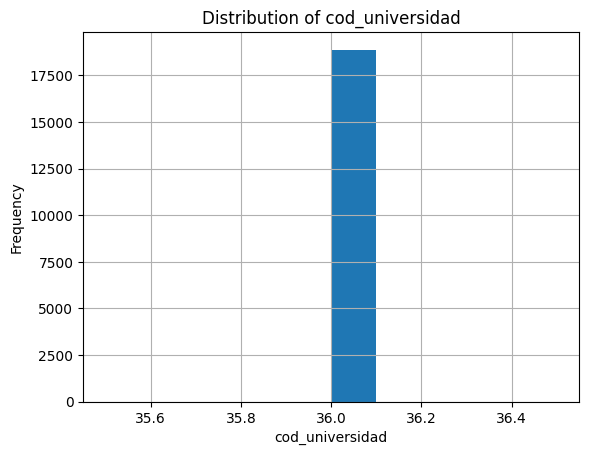

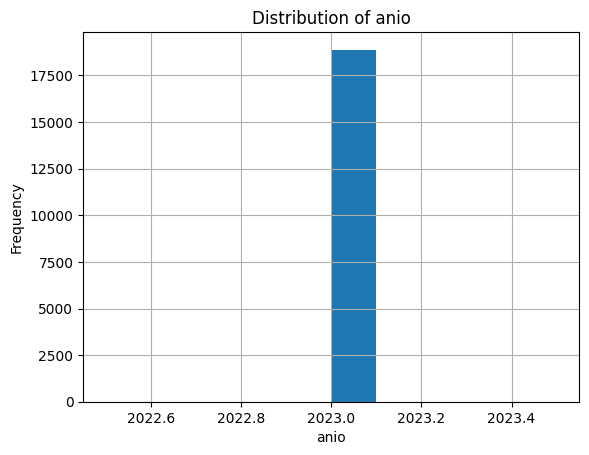

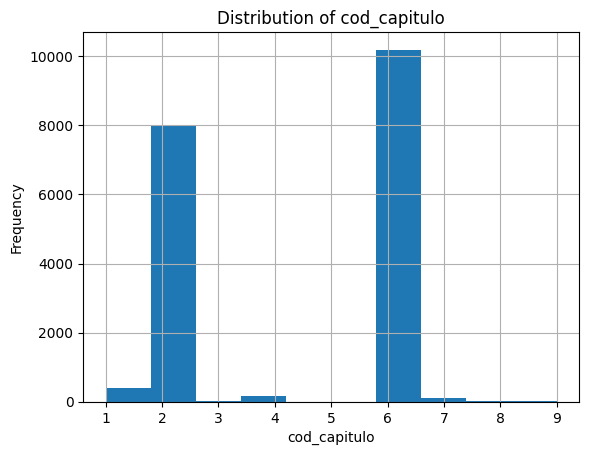

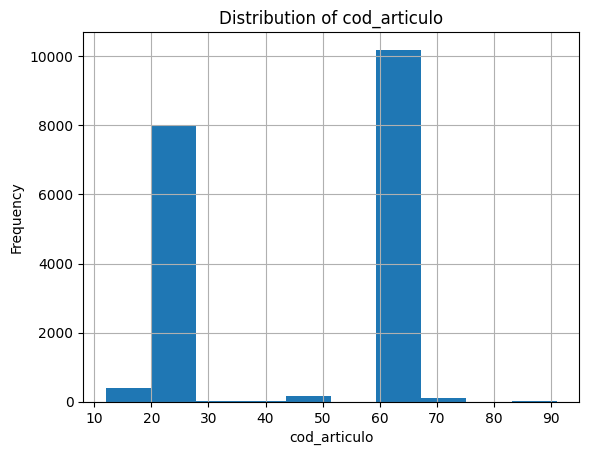

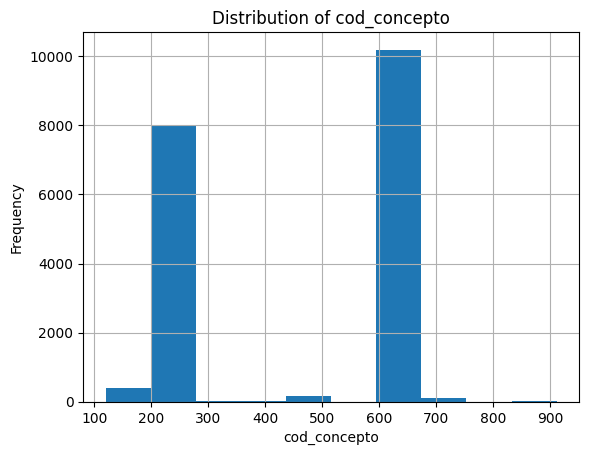

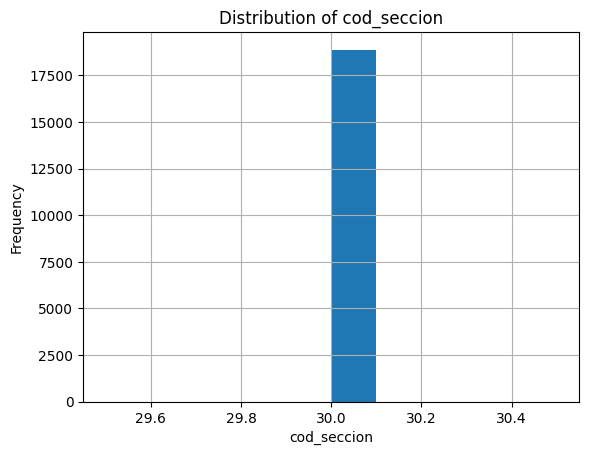

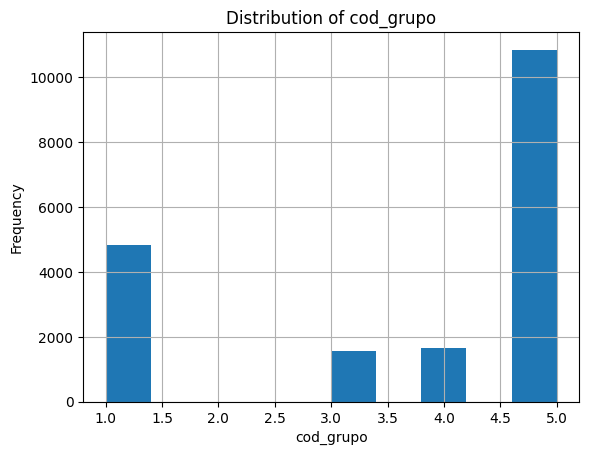

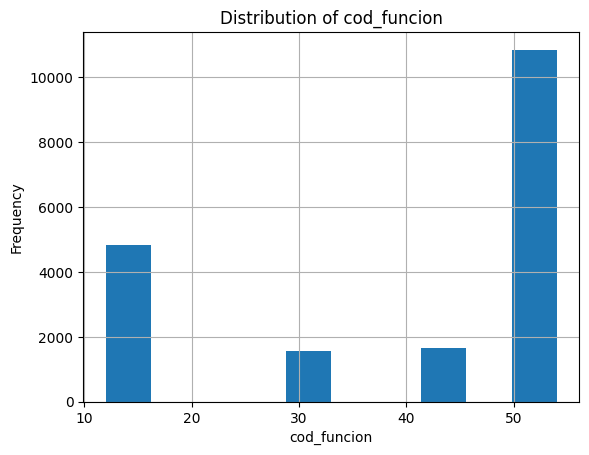

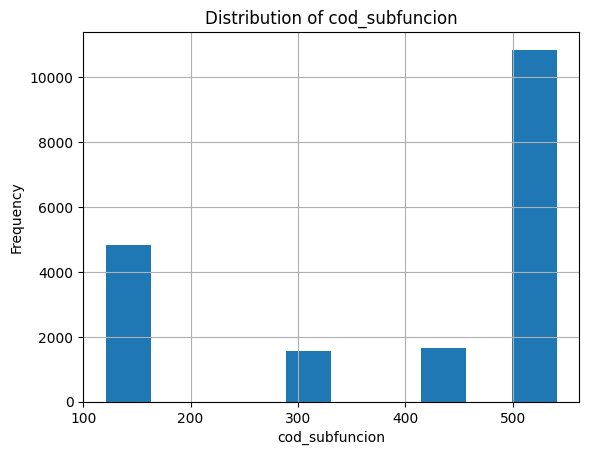

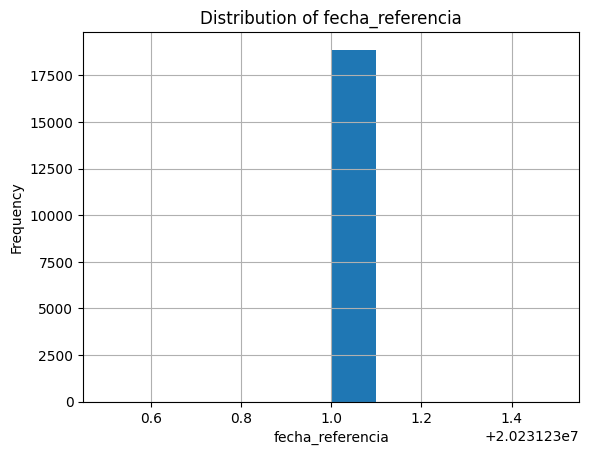

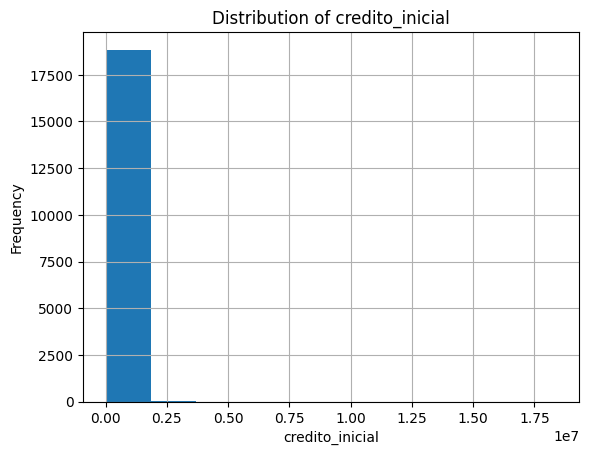

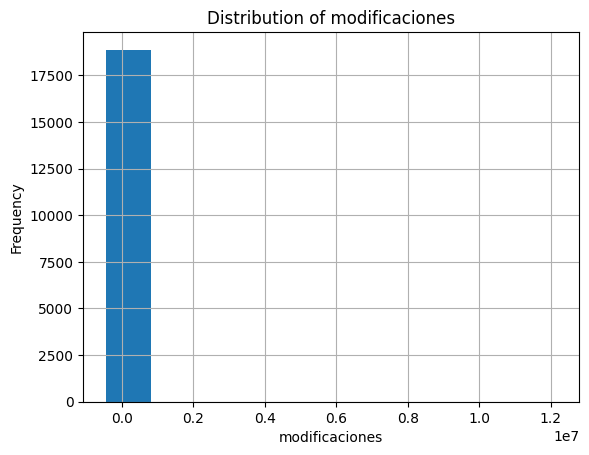

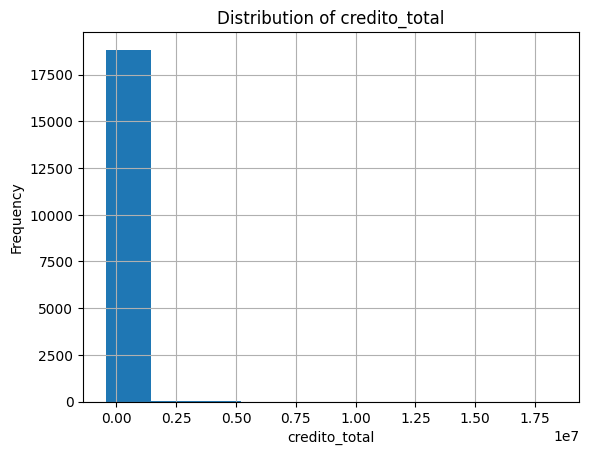

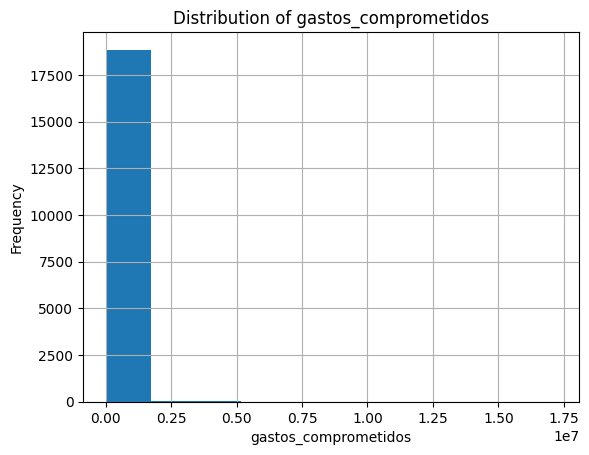

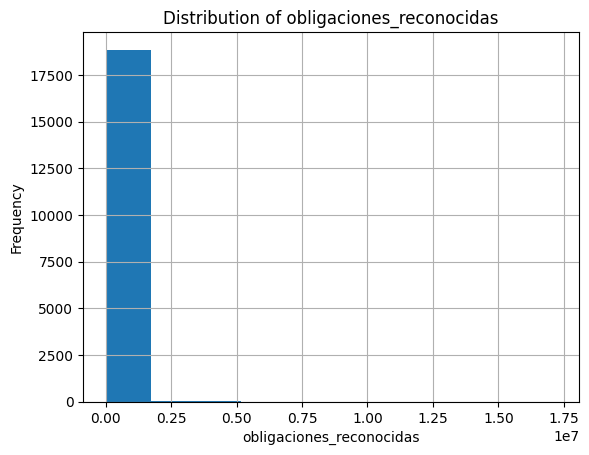

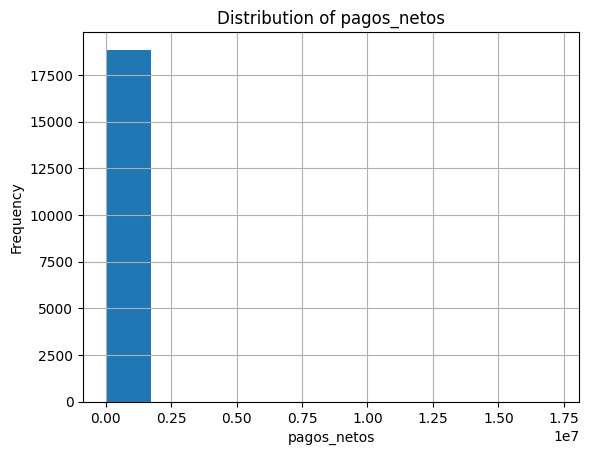


Correlation matrix:
                          cod_universidad  anio  cod_capitulo  cod_articulo  \
cod_universidad                       NaN   NaN           NaN           NaN   
anio                                  NaN   NaN           NaN           NaN   
cod_capitulo                          NaN   NaN      1.000000      0.999176   
cod_articulo                          NaN   NaN      0.999176      1.000000   
cod_concepto                          NaN   NaN      0.999275      0.999949   
cod_seccion                           NaN   NaN           NaN           NaN   
cod_grupo                             NaN   NaN      0.670160      0.675261   
cod_funcion                           NaN   NaN      0.681571      0.686670   
cod_subfuncion                        NaN   NaN      0.680378      0.685484   
fecha_referencia                      NaN   NaN           NaN           NaN   
credito_inicial                       NaN   NaN     -0.031088     -0.030633   
modificaciones                 

In [9]:
#Unique values for categorical columns
cat_cols = df.select_dtypes(include=["object", "category"]).columns
for col in cat_cols:
    print(f"\nUnique values in {col}:")
    print(df[col].value_counts().head(10))

#Histograms for numerical columns
num_cols = df.select_dtypes(include=["int64","float64"]).columns

for col in num_cols:
    plt.figure()
    df[col].hist()
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

Regarding the unique values for the cartegorical values, we can see that the dataset contains records corresponding exclusively to Universidad Carlos III de Madrid. The expenditure structure is mainly concentrated in "Inversiones Reales" and "Gastos corrientes en bienes y servicios". Going more into detail, the most frequent article is "Gastos en inversiones de cáracter inmaterial para proyectos", indicating that a large part of the spending is related to research investments. This is also seen because, regarding the functional purpose, research activities dominate the dataset with 10,861 records, followed by management and administrative activities and teaching. Most expenses are associated with Intercampus activity centers (14,029 records), with smaller contributions from the Getafe (2,604) and Leganés (1,842) campuses.

The histograms of the variables credito_inicial, credito_total, gastos_comprometidos, and obligaciones_reconocidas are strongly right-skewed. Most observations are concentrated at a low value, while a very small number of records show extremely high values. This might suggest applying transformations such as log scale to better analyze data.



**STEP 6: KEEP RELEVANT VARIABLES**

In [ ]:
cols = [
    "anio",
    "des_capitulo",
    "des_articulo",
    "des_concepto",
    "des_subconcepto",
    "des_servicio",
    "des_subfuncion",
    "des_programa",
    "credito_total",
    "obligaciones_reconocidas",
    "pagos_netos"
]

df = df[cols]

**STEP 7: ENSURE NUMERIC VARIABLES ARE OF TYPE NUMERIC**

In [ ]:
numeric_cols = ["credito_total", "obligaciones_reconocidas", "pagos_netos"]

for c in numeric_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

**STEP 8: REMOVE ROWS WITH NO SPENDING**

In [ ]:
df = df[df["pagos_netos"] > 0]

**STEP 9: ADEQUATE THE CAMPUS NAMES FOR INTEGRATION**

In [ ]:
df["des_servicio"] = df["des_servicio"].replace({
    "Centros actividad intercampus": "Intercampus",
    "Campus de Getafe": "Getafe",
    "Campus de Leganés": "Leganés",
    "Parque Cientifico": "Leganés"
})

In [ ]:
df["campus_id"] = df["des_servicio"].map({
    "Intercampus": 6,
    "Leganés": 2,
    "Getafe": 3
})

**STEP 10: SAVE IT**

In [ ]:
df.to_excel("CLEAN(gastos_uc3m).xlsx", index=False)